## 1. Imports and reproducibility

In [ ]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, precision_recall_curve
)

SEED = 42

def set_all_seeds(seed):
    # sets the Python, NumPy and TensorFlow seeds together
    keras.utils.set_random_seed(seed)

set_all_seeds(SEED)

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("Seed       :", SEED)

TensorFlow : 2.20.0
NumPy      : 2.1.3
Pandas     : 2.2.3
Seed       : 42


## 2. Paths and loading the group's processed data
The common notebook already did the cleaning (1,081 duplicate rows removed → 283,726 rows, 473 frauds), the stratified split, and the scaling of `Time` and `Amount` (`V1`–`V28` are already PCA components). Here we only **load** those files.

Edit `PROJECT_DIR` if your folder is different.

In [ ]:
PROJECT_DIR = os.environ.get("PROJECT_DIR")
if PROJECT_DIR is None:
    try:                                   # Google Colab
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_DIR = "/content/drive/MyDrive/Credit-Card-Fraud-Detection"
    except ImportError:                    # local run: notebook is inside a sub-folder of the repo
        PROJECT_DIR = ".."

DATA_DIR  = os.path.join(PROJECT_DIR, "processed_data")
FIG_DIR   = os.path.join(PROJECT_DIR, "results", "figures", "MLP")
TABLE_DIR = os.path.join(PROJECT_DIR, "results", "tables")
MODEL_DIR = os.path.join(PROJECT_DIR, "models", "MLP")
for d in (FIG_DIR, TABLE_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

def load_csv(name):
    return pd.read_csv(os.path.join(DATA_DIR, name)).values

X_train = load_csv("X_train.csv").astype("float32")
X_val   = load_csv("X_val.csv").astype("float32")
X_test  = load_csv("X_test.csv").astype("float32")
y_train = load_csv("y_train.csv").ravel().astype("int32")
y_val   = load_csv("y_val.csv").ravel().astype("int32")
y_test  = load_csv("y_test.csv").ravel().astype("int32")

N_FEATURES = X_train.shape[1]

# ---- sanity checks (fail early if the wrong files were loaded) ----
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    assert X.shape[0] == y.shape[0], f"{name}: X and y have different lengths"
    assert X.shape[1] == N_FEATURES, f"{name}: wrong number of features"
    assert not np.isnan(X).any(), f"{name}: NaN in features"
    assert set(np.unique(y)) <= {0, 1}, f"{name}: target is not binary"

split_table = pd.DataFrame({
    "rows":   [len(y_train), len(y_val), len(y_test)],
    "fraud":  [y_train.sum(), y_val.sum(), y_test.sum()],
}, index=["train", "validation", "test"])
split_table["fraud_%"] = (split_table["fraud"] / split_table["rows"] * 100).round(3)
split_table["share_of_data_%"] = (split_table["rows"] / split_table["rows"].sum() * 100).round(1)
display(split_table)
print("Features:", N_FEATURES)

Mounted at /content/drive


,rows,fraud,fraud_%,share_of_data_%
train,184421,307,0.166,65.0
validation,42559,71,0.167,15.0
test,56746,95,0.167,20.0


Features: 30


## 3. Helper functions
* `evaluate()` – accuracy, precision, recall, F1, ROC-AUC, **PR-AUC**, MCC and the confusion-matrix counts.
* `best_f1_threshold()` – picks the decision threshold on the **validation** set.
* `make_class_weight()` – cost-sensitive learning, computed from **training labels only**.

**Why these metrics?** A model that says "genuine" for every transaction gets 99.83 % accuracy, so accuracy is almost useless here. Recall shows how many frauds are caught, precision shows how many alerts are real, and PR-AUC summarises the precision/recall trade-off and is more informative than ROC-AUC when positives are this rare.

In [ ]:
def evaluate(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy":  accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "f1":        f1_score(y_true, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, prob),
        "pr_auc":    average_precision_score(y_true, prob),
        "mcc":       matthews_corrcoef(y_true, pred),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def best_f1_threshold(y_true, prob):
    # threshold that maximises F1 (use validation data only!)
    p, r, t = precision_recall_curve(y_true, prob)
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    i = int(np.argmax(f1))
    return float(t[i]), float(f1[i])

def make_class_weight(y, mode):
    n0, n1 = int((y == 0).sum()), int((y == 1).sum())
    if mode == "balanced":            # sklearn formula: n / (2 * n_c)
        w = compute_class_weight("balanced", classes=np.array([0, 1]), y=y)
        return {0: float(w[0]), 1: float(w[1])}
    if mode == "sqrt":                # softer weight: sqrt(n0 / n1)
        return {0: 1.0, 1: float(np.sqrt(n0 / n1))}
    if mode == "none":
        return None
    raise ValueError(mode)

for m in ["balanced", "sqrt", "none"]:
    print(f"class weights ({m:8s}):", make_class_weight(y_train, m))

class weights (balanced): {0: 0.5008337225849202, 1: 300.3599348534202}
class weights (sqrt    ): {0: 1.0, 1: 24.489178624585197}
class weights (none    ): None


## 4. Baseline (not counted as a deep-learning model)
A class-weighted **logistic regression** gives a reference point. If the MLP cannot beat it, the extra complexity is not justified. It is trained on the training set and compared on the validation set here; its test result appears only in Section 9.

In [ ]:
t0 = time.time()
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
logreg.fit(X_train, y_train)
logreg_train_time = time.time() - t0

lr_val_prob = logreg.predict_proba(X_val)[:, 1]
lr_thr, _ = best_f1_threshold(y_val, lr_val_prob)

print(f"Logistic regression trained in {logreg_train_time:.1f}s")
display(pd.DataFrame({
    "val @ 0.5":            evaluate(y_val, lr_val_prob, 0.5),
    "val @ tuned threshold": evaluate(y_val, lr_val_prob, lr_thr),
}).T.round(4))

Logistic regression trained in 5.3s


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
val @ 0.5,0.5,0.9731,0.0533,0.9014,0.1007,0.9726,0.814,0.2156,41352.0,1136.0,7.0,64.0
val @ tuned threshold,1.0,0.9996,0.9091,0.8451,0.8759,0.9726,0.814,0.8763,42482.0,6.0,11.0,60.0


## 5. MLP architecture
Input (30) → Dense 64 → Dropout → Dense 32 → Dropout → Dense 16 → Dense 1 (sigmoid)

| Choice | Reason |
|---|---|
| **Dense layers, ReLU** | Inputs are 30 numeric, already-scaled features with no spatial or time structure, so a fully-connected network fits. ReLU is cheap and avoids vanishing gradients. |
| **Funnel shape (64→32→16)** | Gradually compresses the PCA-type features into a compact representation. The size is tuned in Section 6. |
| **Dropout** | Only ~300 fraud rows exist in the training set, so the network can easily memorise them. Dropout is used as regularisation. |
| **Sigmoid output + binary cross-entropy** | Gives a fraud probability for a two-class problem. |
| **Adam optimiser** | Adaptive learning rate, robust default for tabular data. |
| **Class weights** | Cost-sensitive learning: mistakes on the rare fraud class cost more. Unlike over-sampling, no synthetic rows are added, so no risk of leakage into the validation data. |
| **Early stopping on validation PR-AUC** | Stops when the validation PR-AUC no longer improves and restores the best weights (prevents over-fitting, and the saved model really is the best epoch). |

In [ ]:
def build_mlp(hidden_units=(64, 32, 16), dropout=0.3, lr=1e-3, n_features=N_FEATURES):
    model = keras.Sequential(name="mlp")
    model.add(layers.Input(shape=(n_features,)))
    for i, units in enumerate(hidden_units):
        model.add(layers.Dense(units, activation="relu"))
        if dropout > 0 and i < len(hidden_units) - 1:   # no dropout right before the last hidden layer's output
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model

build_mlp().summary()

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

### Training function
`train_mlp()` trains one configuration with one seed. Validation data is used only for early stopping and model selection.

In [ ]:
EPOCHS   = 40      # upper limit; early stopping normally stops earlier
PATIENCE = 6

def train_mlp(cfg, seed, epochs=EPOCHS, verbose=0):
    set_all_seeds(seed)
    model = build_mlp(cfg["hidden_units"], cfg["dropout"], cfg["lr"])
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=PATIENCE, restore_best_weights=True
    )
    t0 = time.time()
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=cfg["batch_size"],
        class_weight=make_class_weight(y_train, cfg["class_weight"]),
        callbacks=[early_stop],
        verbose=verbose,
    )
    train_time = time.time() - t0
    best_epoch = int(np.argmax(hist.history["val_pr_auc"])) + 1
    return model, hist.history, train_time, best_epoch

## 6. Hyperparameter tuning (training + validation data only)
One factor is changed at a time from the base configuration (class-weight strategy, network size, dropout, learning rate, batch size).  
**Selection metric: validation PR-AUC** (accuracy would be misleading). Test data is not used here.

*Limitation to mention in the report:* one-factor-at-a-time search ignores interactions between settings, and the validation set contains only a few dozen frauds, so differences smaller than about 0.01 in PR-AUC are within noise.

In [ ]:
BASE_CFG = dict(hidden_units=(64, 32, 16), dropout=0.3, lr=1e-3, batch_size=256, class_weight="balanced")

search_space = [
    ("base",             {}),
    ("cw_sqrt",          {"class_weight": "sqrt"}),
    ("cw_none",          {"class_weight": "none"}),
    ("small_32_16",      {"hidden_units": (32, 16)}),
    ("large_128_64_32",  {"hidden_units": (128, 64, 32)}),
    ("dropout_0.2",      {"dropout": 0.2}),
    ("dropout_0.5",      {"dropout": 0.5}),
    ("lr_3e-4",          {"lr": 3e-4}),
    ("batch_512",        {"batch_size": 512}),
]

tuning_rows, tuning_cfgs = [], {}
for name, change in search_space:
    cfg = {**BASE_CFG, **change}
    tuning_cfgs[name] = cfg
    model, hist, t_train, best_ep = train_mlp(cfg, SEED)
    val_prob = model.predict(X_val, batch_size=4096, verbose=0).ravel()
    thr, best_f1 = best_f1_threshold(y_val, val_prob)
    m05 = evaluate(y_val, val_prob, 0.5)
    tuning_rows.append({
        "config": name,
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_best_f1": best_f1,
        "val_best_f1_threshold": thr,
        "val_precision@0.5": m05["precision"],
        "val_recall@0.5": m05["recall"],
        "best_epoch": best_ep,
        "epochs_run": len(hist["loss"]),
        "train_time_s": t_train,
        "parameters": model.count_params(),
    })
    print(f"{name:16s} val PR-AUC={tuning_rows[-1]['val_pr_auc']:.4f}  "
          f"best epoch={best_ep:2d}  time={t_train:5.1f}s")
    keras.backend.clear_session()

tuning_df = pd.DataFrame(tuning_rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
tuning_df.to_csv(os.path.join(TABLE_DIR, "MLP_tuning_results.csv"), index=False)
display(tuning_df.round(4))

base             val PR-AUC=0.7923  best epoch=21  time= 95.9s
cw_sqrt          val PR-AUC=0.8738  best epoch=25  time=114.1s
cw_none          val PR-AUC=0.8800  best epoch=19  time= 87.2s
small_32_16      val PR-AUC=0.7864  best epoch= 1  time= 23.7s
large_128_64_32  val PR-AUC=0.8024  best epoch= 3  time= 42.9s
dropout_0.2      val PR-AUC=0.8135  best epoch= 9  time= 58.0s
dropout_0.5      val PR-AUC=0.8292  best epoch=14  time= 72.2s
lr_3e-4          val PR-AUC=0.8101  best epoch= 9  time= 53.2s
batch_512        val PR-AUC=0.8053  best epoch= 3  time= 24.5s


,config,val_pr_auc,val_roc_auc,val_best_f1,val_best_f1_threshold,val_precision@0.5,val_recall@0.5,best_epoch,epochs_run,train_time_s,parameters
0,cw_none,0.8800,0.9762,0.9104,0.6207,0.9104,0.8592,19,25,87.2252,4609
1,cw_sqrt,0.8738,0.9712,0.8732,0.8283,0.6966,0.8732,25,31,114.0662,4609
2,dropout_0.5,0.8292,0.9738,0.8652,0.9705,0.0637,0.8873,14,20,72.1601,4609
3,dropout_0.2,0.8135,0.9748,0.8714,0.9953,0.0641,0.9014,9,15,58.0188,4609
4,lr_3e-4,0.8101,0.9729,0.8633,0.9956,0.0564,0.9155,9,15,53.2260,4609
5,batch_512,0.8053,0.9724,0.8633,0.9962,0.0554,0.8873,3,9,24.4706,4609
6,large_128_64_32,0.8024,0.9753,0.8759,0.9967,0.0640,0.9155,3,9,42.9270,14337
7,base,0.7923,0.9747,0.8633,0.9961,0.0682,0.9155,21,27,95.8543,4609
8,small_32_16,0.7864,0.9764,0.8571,0.9830,0.0895,0.9014,1,7,23.7232,1537


In [ ]:
BEST_NAME = tuning_df.loc[0, "config"]
BEST_CFG  = tuning_cfgs[BEST_NAME]
print("Selected configuration:", BEST_NAME)
print(BEST_CFG)

## 7. Final training with several random seeds
The selected configuration is trained with 5 different seeds (`SEEDS` below). This shows how **stable** the result is (mean ± standard deviation), which a single run cannot show.  
For each seed the decision threshold is chosen on the **validation** set. The seed-42 run is kept as the "primary" model for the plots.

In [ ]:
SEEDS = [42, 7, 123, 2024, 99]

seed_records, primary = [], None
for s in SEEDS:
    model, hist, t_train, best_ep = train_mlp(BEST_CFG, s)

    val_prob = model.predict(X_val, batch_size=4096, verbose=0).ravel()
    thr, _   = best_f1_threshold(y_val, val_prob)          # threshold from validation only

    t0 = time.time()
    test_prob = model.predict(X_test, batch_size=4096, verbose=0).ravel()
    infer_time = time.time() - t0

    # ---- FINAL EVALUATION: the only place the test set is used ----
    for label, th in [("0.5", 0.5), ("val-tuned", thr)]:
        seed_records.append({"seed": s, "threshold_type": label, **evaluate(y_test, test_prob, th),
                             "best_epoch": best_ep, "epochs_run": len(hist["loss"]),
                             "train_time_s": t_train, "inference_time_s": infer_time,
                             "parameters": model.count_params()})
    print(f"seed {s:5d}: best epoch {best_ep:2d}, train {t_train:5.1f}s, val-tuned threshold {thr:.3f}")

    if s == SEED:
        primary = dict(model=model, hist=hist, val_prob=val_prob, test_prob=test_prob,
                       threshold=thr, train_time=t_train, best_epoch=best_ep, infer_time=infer_time)
    else:
        keras.backend.clear_session()

seed_df = pd.DataFrame(seed_records)

## 8. Learning curves (primary model, seed 42)
**Read with care:** Keras applies the class weights to the *training* loss but not to the *validation* loss, so the two loss curves are not on the same scale (the validation loss can look lower than the training loss without the model generalising better). The PR-AUC and recall curves are comparable.

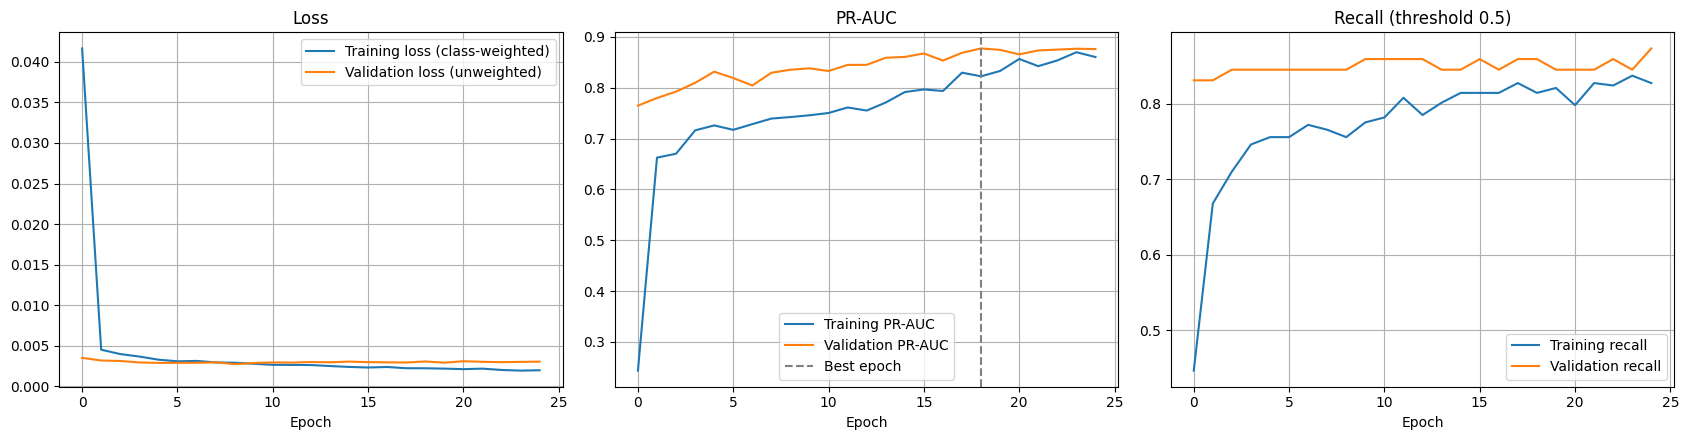

In [19]:
h = primary["hist"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(h["loss"], label="Training loss (class-weighted)")
axes[0].plot(h["val_loss"], label="Validation loss (unweighted)")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(h["pr_auc"], label="Training PR-AUC")
axes[1].plot(h["val_pr_auc"], label="Validation PR-AUC")
axes[1].axvline(primary["best_epoch"] - 1, color="grey", linestyle="--", label="Best epoch")
axes[1].set_title("PR-AUC"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(h["recall"], label="Training recall")
axes[2].plot(h["val_recall"], label="Validation recall")
axes[2].set_title("Recall (threshold 0.5)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "learning_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## 9. Final test-set evaluation
Primary model (seed 42) versus the logistic-regression baseline, each at the default threshold 0.5 and at the threshold chosen on the validation set.

In [20]:
y_prob = primary["test_prob"]
thr    = primary["threshold"]
lr_test_prob = logreg.predict_proba(X_test)[:, 1]

rows = {
    "MLP @ 0.5":                    evaluate(y_test, y_prob, 0.5),
    f"MLP @ val-tuned ({thr:.3f})":  evaluate(y_test, y_prob, thr),
    "LogReg @ 0.5":                 evaluate(y_test, lr_test_prob, 0.5),
    f"LogReg @ val-tuned ({lr_thr:.3f})": evaluate(y_test, lr_test_prob, lr_thr),
}
test_table = pd.DataFrame(rows).T
test_table[["tp", "fn", "fp", "tn"]] = test_table[["tp", "fn", "fp", "tn"]].astype(int)
display(test_table[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "mcc", "tp", "fn", "fp", "tn"]].round(4))

print("Classification report – MLP at the validation-tuned threshold")
print(classification_report(y_test, (y_prob >= thr).astype(int), target_names=["Genuine", "Fraud"], digits=4))

,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,tp,fn,fp,tn
MLP @ 0.5,0.9994,0.8987,0.7474,0.8161,0.9595,0.8007,0.8193,71,24,8,56643
MLP @ val-tuned (0.621),0.9994,0.9200,0.7263,0.8118,0.9595,0.8007,0.8172,69,26,6,56645
LogReg @ 0.5,0.9721,0.0502,0.8737,0.0949,0.9617,0.6848,0.2056,83,12,1571,55080
LogReg @ val-tuned (1.000),0.9994,0.8391,0.7684,0.8022,0.9617,0.6848,0.8027,73,22,14,56637


Classification report – MLP at the validation-tuned threshold
              precision    recall  f1-score   support

     Genuine     0.9995    0.9999    0.9997     56651
       Fraud     0.9200    0.7263    0.8118        95

    accuracy                         0.9994     56746
   macro avg     0.9598    0.8631    0.9057     56746
weighted avg     0.9994    0.9994    0.9994     56746



### Confusion matrices, ROC curve and precision–recall curve

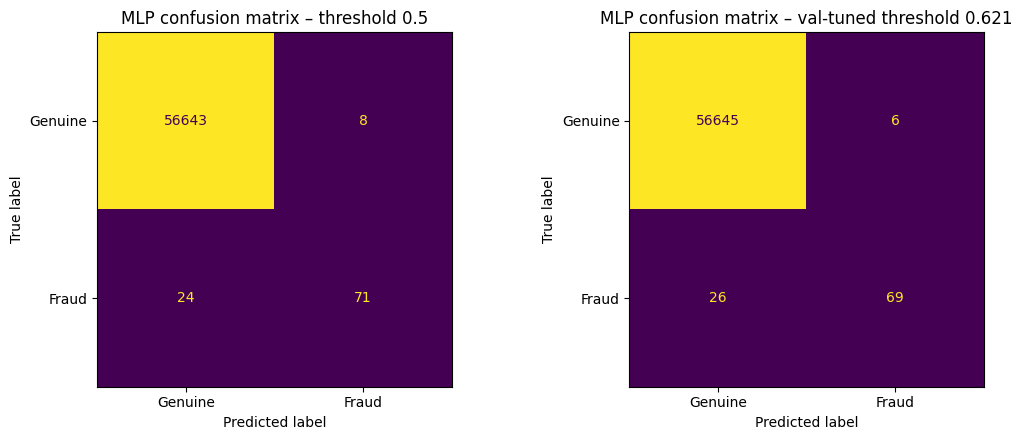

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, th) in zip(axes, [("threshold 0.5", 0.5), (f"val-tuned threshold {thr:.3f}", thr)]):
    cm = confusion_matrix(y_test, (y_prob >= th).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["Genuine", "Fraud"]).plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"MLP confusion matrix – {title}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"), dpi=300, bbox_inches="tight")
plt.show()

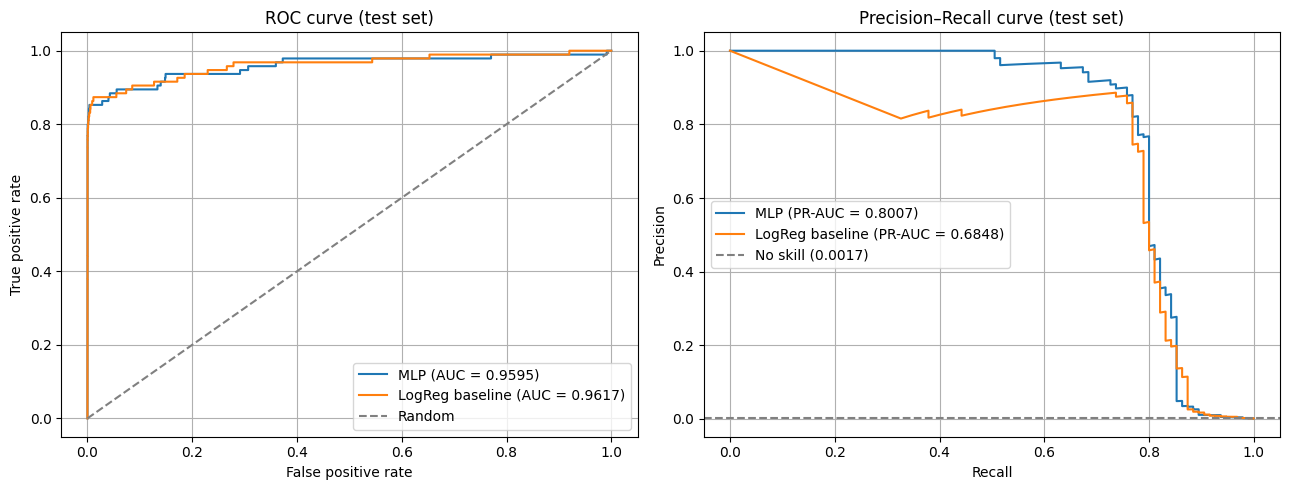

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, prob in [("MLP", y_prob), ("LogReg baseline", lr_test_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.4f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Random")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test set)"); axes[0].legend(); axes[0].grid(True)

# Precision-Recall
for name, prob in [("MLP", y_prob), ("LogReg baseline", lr_test_prob)]:
    p, r, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(r, p, label=f"{name} (PR-AUC = {average_precision_score(y_test, prob):.4f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"No skill ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curve (test set)"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "roc_and_pr_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Error analysis
Where does the model fail? Predicted fraud probabilities for genuine and fraud transactions, and the frauds that were missed.

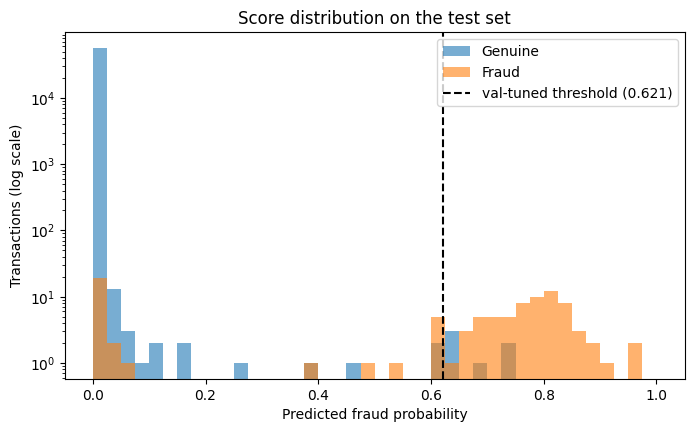

Frauds in test set        : 95
Missed frauds (FN)        : 26
False alarms (FP)         : 6
Predicted probability of each missed fraud: [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e-04 1.000e-04 2.000e-04
 3.900e-03 5.400e-03 5.800e-03 8.100e-03 1.060e-02 3.470e-02 4.050e-02
 6.330e-02 3.826e-01 4.874e-01 5.304e-01 6.196e-01]


In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 41)
ax.hist(y_prob[y_test == 0], bins=bins, alpha=0.6, label="Genuine", log=True)
ax.hist(y_prob[y_test == 1], bins=bins, alpha=0.6, label="Fraud",   log=True)
ax.axvline(thr, color="k", linestyle="--", label=f"val-tuned threshold ({thr:.3f})")
ax.set_xlabel("Predicted fraud probability"); ax.set_ylabel("Transactions (log scale)")
ax.set_title("Score distribution on the test set"); ax.legend()
plt.savefig(os.path.join(FIG_DIR, "score_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

pred_tuned = (y_prob >= thr).astype(int)
missed = np.where((y_test == 1) & (pred_tuned == 0))[0]
false_alarms = int(((y_test == 0) & (pred_tuned == 1)).sum())
print(f"Frauds in test set        : {int(y_test.sum())}")
print(f"Missed frauds (FN)        : {len(missed)}")
print(f"False alarms (FP)         : {false_alarms}")
print("Predicted probability of each missed fraud:", np.round(np.sort(y_prob[missed]), 4))

## 11. Stability and efficiency
Mean ± standard deviation over the seeds (test set), the training cost, and the model size.

In [ ]:
metric_cols = ["precision", "recall", "f1", "roc_auc", "pr_auc", "mcc"]
summary = (seed_df.groupby("threshold_type")[metric_cols].agg(["mean", "std"]).round(4))
display(summary)

eff = pd.DataFrame({
    "Model": [f"MLP (mean of {len(SEEDS)} seeds)", "Logistic regression"],
    "Parameters": [int(seed_df["parameters"].iloc[0]), N_FEATURES + 1],
    "Training time (s)": [round(seed_df.groupby("seed")["train_time_s"].first().mean(), 1), round(logreg_train_time, 1)],
    "Epochs until best": [round(seed_df.groupby("seed")["best_epoch"].first().mean(), 1), "-"],
})
display(eff)

## 12. Save model, configuration and results
Saved so the group can build the final comparison table and so the results can be reproduced.

In [ ]:
primary["model"].save(os.path.join(MODEL_DIR, "MLP_best_model.keras"))

test_table.round(6).to_csv(os.path.join(TABLE_DIR, "MLP_results.csv"))
seed_df.round(6).to_csv(os.path.join(TABLE_DIR, "MLP_multiseed_results.csv"), index=False)

config = {
    "seed": SEED, "seeds_used": SEEDS,
    "selected_config_name": BEST_NAME,
    "selected_config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in BEST_CFG.items()},
    "epochs_max": EPOCHS, "early_stopping": {"monitor": "val_pr_auc", "patience": PATIENCE},
    "val_tuned_threshold_seed42": thr,
    "data_dir": DATA_DIR,
    "versions": {"tensorflow": tf.__version__, "numpy": np.__version__, "pandas": pd.__version__},
}
with open(os.path.join(MODEL_DIR, "MLP_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Saved model, configuration and result tables.")

## 13. Points to cover in the report's *Critical Analysis and Discussion* (30 % of the marks)
Fill these in from **your own outputs above**; do not copy numbers from an older run.

* **Threshold effect:** compare the confusion matrices at 0.5 and at the validation-tuned threshold: how many false alarms are removed, how many frauds are lost?
* **Class-weight strategy:** what did `balanced` vs `sqrt` vs `none` do to precision and recall in the tuning table, and why?
* **Overfitting / generalisation:** training vs validation PR-AUC curves, best epoch, and the validation → test gap. Remember the training loss is class-weighted and the validation loss is not.
* **Stability:** the standard deviation over 5 seeds; with so few frauds in the test set, one missed fraud moves recall by about 1 percentage point.
* **Baseline:** does the MLP beat logistic regression on PR-AUC, and is the gain worth the extra cost (parameters, training time)?
* **Errors:** what do the missed frauds look like in the score histogram (low scores = the model is confident they are genuine)?
* **Limitations:** anonymised PCA features (no feature engineering possible), a single time-agnostic random split (in reality fraud drifts over time), and the small number of fraud cases.
* **Future work:** temporal split, focal loss, threshold chosen by business cost, ensembling, and comparison with the group's other models under the same split.